# **Modelo mensual de predicción de new_churn_t+1**

## Importar librerias

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix, classification_report, precision_recall_curve, recall_score
import matplotlib.pyplot as plt

## Preparación
- Filtrar datos: mantener solo CABA y eliminar datos de septiembre 2025 (09-2025)
- Nuevas features:
    - Lag (-1): tpn, gmv
    - Lag (-2): tpn, gmv
    - MoM (%): tpn, gmv
    - Antigüedad de la store (en meses)
    - Variable de fecha pasan a ser ciclicas
- Encoding de categoricas
    - category (freq encoder)
    - barrio (freq encoder)
    - segmento (one-hot)
- Drop de columnas innecesarias

In [13]:
monthly_master = pd.read_csv('data/processed/monthly_master.csv')

monthly_master.columns

Index(['store_id', 'period_month', 'tpn', 'gmv', 'days_with_orders',
       'markdown_mean', 'avg_shipping_cost', 'si_ios_prop', 'si_meli_prop',
       'si_other_prop', 'free_shipping_prop', 'churn', 'churn_streak',
       'churn_2m_consec', 'churn_4m_consec_or_more', 'churn_unique', 'stage',
       'created_date', 'segmento', 'comision_actual', 'in-house_delivery',
       'store_type', 'barrio', 'category', 'cooking_time', 'tiene_otra_app',
       'brand_id', 'ciudad', 'total_min_open', 'total_min_paused',
       'total_min_closed', 'total_minutes_all'],
      dtype='object')

In [14]:
monthly_master_new = monthly_master.copy()

Filtrar datos: mantener solo CABA y eliminar datos de septiembre 2025 (09-2025)

In [15]:
# Filtrar solo datos de CABA
monthly_master_new = monthly_master_new[monthly_master_new['ciudad'] == 'CABA']

# Convertir las columnas de fecha a tipo datetime
monthly_master_new["created_date"] = pd.to_datetime(monthly_master_new["created_date"])
monthly_master_new["period_date"] = pd.to_datetime(monthly_master_new["period_month"], format="%Y-%m")

monthly_master_new = monthly_master_new.sort_values(["store_id","period_date"]).reset_index(drop=True)

# Quedarse solo con datos hasta agosto 2025 (ya que septiembre 2025 está incompleto)
monthly_master_new = monthly_master_new[monthly_master_new['period_date'] < '2025-09-01']

monthly_master_new.rename(columns={'churn_unique': 'new_churn'}, inplace=True)

Creamos la variable target (churn_t+1)

In [16]:
# Crear variable target (new_churn_t+1)
monthly_master_new["new_churn_t+1"] = monthly_master_new.groupby("store_id")["new_churn"].shift(-1)

Nuevas features temporales:
- Lag (-1): tpn, gmv
- Lag (-2): tpn, gmv
- MoM (%): tpn, gmv
- Antigüedad de la store (en meses)
- Variable de fecha pasan a ser ciclicas

In [17]:
# Nuevas variables temporales (lag)

# --- LAG FEATURES and Mom% for tpn and gmv ---
for col in ["tpn","gmv"]:
    # lag t-1 and t-2
    monthly_master_new[f"{col}_t-1"] = monthly_master_new.groupby("store_id")[col].shift(1)
    monthly_master_new[f"{col}_t-2"] = monthly_master_new.groupby("store_id")[col].shift(2)
    # month-over-month % vs previous month
    monthly_master_new[f"{col}_mom_pct"] = (monthly_master_new[col] - monthly_master_new[f"{col}_t-1"]) / monthly_master_new[f"{col}_t-1"]
    # handle divisions by zero / inf
    monthly_master_new.loc[ monthly_master_new[f"{col}_t-1"] == 0, f"{col}_mom_pct"] = np.nan
    monthly_master_new.loc[ np.isinf(monthly_master_new[f"{col}_mom_pct"]), f"{col}_mom_pct"] = np.nan

In [18]:
# Variables tipo fecha a ciclicas 

    # period-month (variables ciclicas)

monthly_master_new["period_month"] = monthly_master_new["period_date"].dt.month
monthly_master_new["period_month_sin"] = np.sin(2 * np.pi * monthly_master_new["period_month"] / 12)
monthly_master_new["period_month_cos"] = np.cos(2 * np.pi * monthly_master_new["period_month"] / 12)

monthly_master_new["period_year"] = monthly_master_new["period_date"].dt.year
monthly_master_new["period_year_sin"] = np.sin(2 * np.pi * (monthly_master_new["period_year"] - monthly_master_new["period_year"].min()) / (monthly_master_new["period_year"].max() - monthly_master_new["period_year"].min()))
monthly_master_new["period_year_cos"] = np.cos(2 * np.pi * (monthly_master_new["period_year"] - monthly_master_new["period_year"].min()) / (monthly_master_new["period_year"].max() - monthly_master_new["period_year"].min()))

    # created_date (variables ciclicas)

        # created_month (1..12)
monthly_master_new["created_month"] = monthly_master_new["created_date"].dt.month
monthly_master_new["created_month_sin"] = np.sin(2 * np.pi * monthly_master_new["created_month"] / 12)
monthly_master_new["created_month_cos"] = np.cos(2 * np.pi * monthly_master_new["created_month"] / 12)

        # created_year (2020..)
monthly_master_new["created_year"] = monthly_master_new["created_date"].dt.year
monthly_master_new["created_year_sin"] = np.sin(2 * np.pi * (monthly_master_new["created_year"] - monthly_master_new["created_year"].min()) / (monthly_master_new["created_year"].max() - monthly_master_new["created_year"].min()))
monthly_master_new["created_year_cos"] = np.cos(2 * np.pi * (monthly_master_new["created_year"] - monthly_master_new["created_year"].min()) / (monthly_master_new["created_year"].max() - monthly_master_new["created_year"].min()))

        # created_day (1..30)
monthly_master_new["created_day"] = monthly_master_new["created_date"].dt.day
monthly_master_new["created_day_sin"] = np.sin(2 * np.pi * (monthly_master_new["created_day"] - 1) / 30) 
monthly_master_new["created_day_cos"] = np.cos(2 * np.pi * (monthly_master_new["created_day"] - 1) / 30)

# Antigüedad en meses de la store en cada mes (period_date - created_date)
monthly_master_new["antiguedad_meses"] = ((monthly_master_new["period_date"].dt.year - monthly_master_new["created_date"].dt.year) * 12 + (monthly_master_new["period_date"].dt.month - monthly_master_new["created_date"].dt.month)).clip(lower=0).astype(int)

Encoding de variables categoricas

In [19]:
# Encoder de variables categóricas
    # 1) One-Hot para 'segmento' (pocos niveles)
monthly_master_new = pd.get_dummies(monthly_master_new, columns=["segmento"], prefix="seg", drop_first=True)

    # 2) Frequency encoding for 'barrio' and 'category' as a simple baseline
    # frequency = count of occurrences of that category divided by total rows
for col in ["barrio","category"]:
    freq = monthly_master_new[col].value_counts(normalize=True)
    monthly_master_new[f"{col}_freq"] = monthly_master_new[col].map(freq)

In [20]:
# Eliminar columnas innecesarias

monthly_master_new = monthly_master_new.drop(columns=['period_month', 'stage', 'created_date', 'ciudad', 'store_type', 'barrio', 'category'])

In [21]:
monthly_master_new.head()

,store_id,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop,...,created_year_sin,created_year_cos,created_day,created_day_sin,created_day_cos,antiguedad_meses,seg_Picked Locals,seg_Top Players,barrio_freq,category_freq
0,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,15,0.207912,-0.978148,0,False,False,0.069182,0.022069
1,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,15,0.207912,-0.978148,1,False,False,0.069182,0.022069
2,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,15,0.207912,-0.978148,2,False,False,0.069182,0.022069
3,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,15,0.207912,-0.978148,3,False,False,0.069182,0.022069
4,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,15,0.207912,-0.978148,4,False,False,0.069182,0.022069


In [22]:
monthly_master_new.columns

Index(['store_id', 'tpn', 'gmv', 'days_with_orders', 'markdown_mean',
       'avg_shipping_cost', 'si_ios_prop', 'si_meli_prop', 'si_other_prop',
       'free_shipping_prop', 'churn', 'churn_streak', 'churn_2m_consec',
       'churn_4m_consec_or_more', 'new_churn', 'comision_actual',
       'in-house_delivery', 'cooking_time', 'tiene_otra_app', 'brand_id',
       'total_min_open', 'total_min_paused', 'total_min_closed',
       'total_minutes_all', 'period_date', 'new_churn_t+1', 'tpn_t-1',
       'tpn_t-2', 'tpn_mom_pct', 'gmv_t-1', 'gmv_t-2', 'gmv_mom_pct',
       'period_month_sin', 'period_month_cos', 'period_year',
       'period_year_sin', 'period_year_cos', 'created_month',
       'created_month_sin', 'created_month_cos', 'created_year',
       'created_year_sin', 'created_year_cos', 'created_day',
       'created_day_sin', 'created_day_cos', 'antiguedad_meses',
       'seg_Picked Locals', 'seg_Top Players', 'barrio_freq', 'category_freq'],
      dtype='object')

## Entrenamiento del modelo

### División train y test

In [23]:
# --------------------------
# CONFIG (ajustá según tu caso)
# --------------------------

TARGET_COL = 'new_churn_t+1'          # target 0/1

# Columnas categóricas a frequency-encode (si no las tenés ya encoded)
# FREQ_ENC_COLS = ['barrio','category']  # si ya hiciste barrio_freq/category_freq podés dejar vacío

# Ajustá TEST_YEAR_MONTH (formato 'YYYY-MM') al agosto que querés usar como test.
TEST_YEAR_MONTH = '2025-07'  # test en julio 2025 (predecir churn_t+1 osea agosto 2025)
TEST_PERIOD = pd.to_datetime(TEST_YEAR_MONTH + '-01')

In [24]:
# filas con target NaN no se usan para entrenamiento, pero pueden incluirse en producción
df_trainable = monthly_master_new[~monthly_master_new[TARGET_COL].isna()].copy().reset_index(drop=True)

In [25]:
# Construir test set: filas cuyo period_date == TEST_PERIOD
test_idx = df_trainable[df_trainable['period_date'] == TEST_PERIOD].index

# Considerar todas las demás filas como train (train )
train_idx = df_trainable.index.difference(test_idx)

In [26]:
# split X/y
X = df_trainable.drop(columns=[TARGET_COL]).copy()
y = df_trainable[TARGET_COL].astype(int).copy()

X_test = X.loc[test_idx].copy()
X_test = X_test.drop(columns=['period_date'])
y_test = y.loc[test_idx].copy()

X_train = X.loc[train_idx].copy()
X_train = X_train.drop(columns=['period_date'])
y_train = y.loc[train_idx].copy()

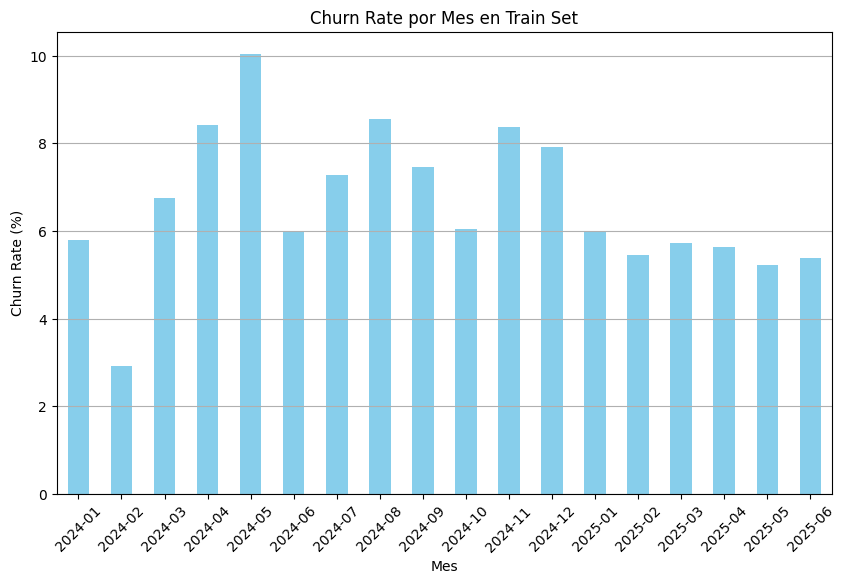

In [27]:
# Grafico de desbalanceo de variable target en train por mes (en porcentaje sobre total de stores en ese mes)
train_df = df_trainable.loc[train_idx].copy()
train_df['period_month'] = train_df['period_date'].dt.to_period('M')
churn_rate_by_month = train_df.groupby('period_month')[TARGET_COL].mean()*100
churn_rate_by_month.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Churn Rate por Mes en Train Set')
plt.xlabel('Mes')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [28]:
y_train.value_counts(normalize=True)

new_churn_t+1
0    0.936813
1    0.063187
Name: proportion, dtype: float64

El desbalanceo moderado (1-5%) pero no extremo (<1%) mes a mes. Se va a utilizar el argumento de ponderacion de lightgbm para clase positiva minoritaria

### Entrenamiento del modelo

In [29]:
# parámetros LightGBM (baseline)
NUM_BOOST_ROUND = 200
N_JOBS = -1

LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'seed': 42,
    'verbosity': -1,
    'n_jobs': N_JOBS,
    'is_unbalance': True
}

In [30]:
# -------- Entrenar LightGBM --------
dtrain = lgb.Dataset(X_train, label=y_train)
bst = lgb.train(LGB_PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)

# -------- Predicción en test (probabilidades) --------
y_test_pred_proba = bst.predict(X_test, num_iteration=bst.best_iteration or NUM_BOOST_ROUND)

In [31]:
# -------- Métricas (probabilísticas / ranking) --------
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba) if len(np.unique(y_test)) > 1 else np.nan
test_pr_auc = average_precision_score(y_test, y_test_pred_proba) if len(np.unique(y_test)) > 1 else np.nan
test_brier = brier_score_loss(y_test, y_test_pred_proba)

print("Métricas probabilísticas (test):")
print(f"  ROC AUC: {test_roc_auc:.4f}")
print(f"  PR-AUC (Average Precision): {test_pr_auc:.4f}")
print(f"  Brier score: {test_brier:.4f}")
print()

Métricas probabilísticas (test):
  ROC AUC: 0.9290
  PR-AUC (Average Precision): 0.3834
  Brier score: 0.0579



In [35]:
# ---------- 1) confusion matrix y classification report a threshold fijo ----------
TH = 0.5
y_pred_label = (y_test_pred_proba >= TH).astype(int)

print("Matriz de confusión:")
labels = ['Retained', 'Churned']
pd.DataFrame(confusion_matrix(y_test, y_pred_label), index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])

Matriz de confusión:


,Pred_Retained,Pred_Churned
True_Retained,3230,245
True_Churned,58,124


In [36]:
print("Matriz de confusión (proporción de los reales):")
pd.DataFrame(confusion_matrix(y_test, y_pred_label, normalize='true'), index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])

Matriz de confusión (proporción de los reales):


,Pred_Retained,Pred_Churned
True_Retained,0.929496,0.070504
True_Churned,0.318681,0.681319


Dado que el objetivo prioritario es identificar correctamente a las tiendas con riesgo de abandono, se decide emplear como métrica central el Recall, ya que mide la proporción de verdaderos churners detectados sobre el total de churners reales.

Una mayor cantidad de falsos negativos (siendo la clase positiva = churned), indicarian que no se llegó a anticipar el churneo de las stores correctamente.
En cambio, los falsos positivos (osea predecir que va a caer el churn cuando no lo hace realmente) no es tan costoso ya que nosotros no cuantificamos el costo de intervenir una store. Mientras que, los posibles ingresos de MercadoDelivery de intervenir una store a tiempo, si se cuantifica. Por lo tanto, buscamos reducir estos falsos negativos.

In [37]:
print("Classification report (threshold = {:.2f}):".format(TH))
print(classification_report(y_test, y_pred_label, digits=4, zero_division=0))

Classification report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.9824    0.9295    0.9552      3475
           1     0.3360    0.6813    0.4501       182

    accuracy                         0.9171      3657
   macro avg     0.6592    0.8054    0.7026      3657
weighted avg     0.9502    0.9171    0.9301      3657



Observando el recall (de la clase positiva), se puede ver que un 68% de las stores que realmente iban a entrar en churn, fueron predichas correctamente que iban a entrar en churn. A pesar de ser alta la métrica, hay un ~32% de stores que van a churnear en agosto que fueron incorrectamente clasificados como que iban a tener actividad. Esto es de interes ya que implica una perdida de posibles ingresos al no intervenir en esas stores a tiempo.

En cuanto a la precision, un 33% de los que se predijo que iban a caer en churn en agosto, realmente cayeron en churn.

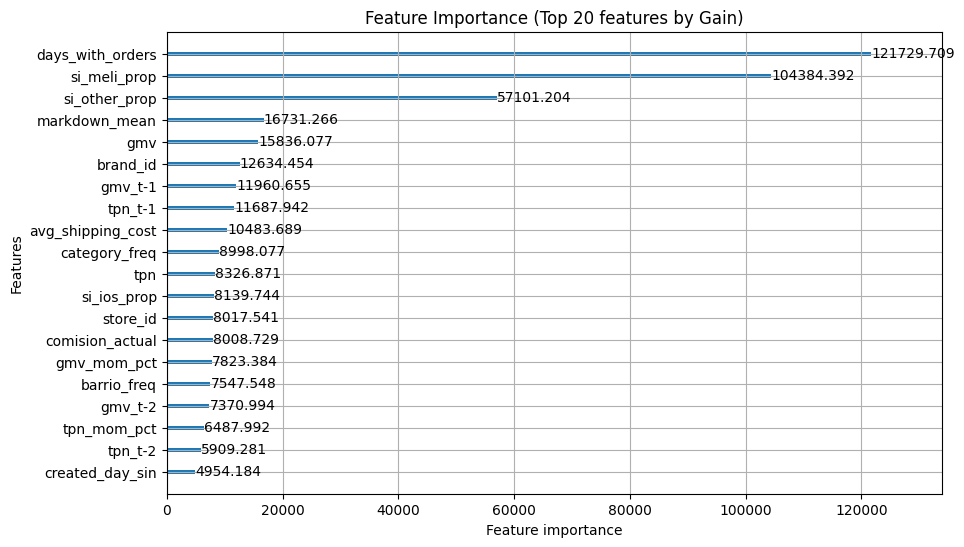

In [38]:
# Ver feature importance del modelo
lgb.plot_importance(bst, max_num_features=20, importance_type='gain', figsize=(10,6))
plt.title('Feature Importance (Top 20 features by Gain)')
plt.show()